<a href="https://colab.research.google.com/github/adit-codez/Assignment-04/blob/main/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_excel("q3_retail_promotions.xlsx")
print("Shape:", df.shape)
display(df.head())
print("Missing values:", df.isnull().sum())
print("Data types:", df.dtypes)

Shape: (1200, 9)


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


Missing values: transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64
Data types: transaction_date       datetime64[ns]
store_id                        int64
store_size                     object
location_type                  object
promotion_type                 object
is_weekend                      int64
is_festival                     int64
competition_density             int64
items_sold                      int64
dtype: object


In [3]:
# Data feature engineering
df["transaction_date"] = pd.to_datetime(df["transaction_date"], dayfirst=True)

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

display(df[[
    "transaction_date", "year", "month", "day_of_week", "is_month_end",
    "store_id", "store_size", "location_type", "promotion_type",
    "is_weekend", "is_festival", "competition_density", "items_sold"
]].head())

,transaction_date,year,month,day_of_week,is_month_end,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,2022,1,5,0,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,2022,1,5,0,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,2022,1,6,0,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,2022,1,6,0,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,2022,1,0,0,50,medium,semi-urban,bogo,0,0,3,277


The date column was converted into useful time-based features: year, month, day_of_week, and is_month_end. These features help the model capture seasonal and calendar-based patterns that may affect sales.

In [4]:
# Temporal Train-Test Split
df = df.sort_values("transaction_date").reset_index(drop=True)

test_size = int(len(df) * 0.2)
train_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df["transaction_date"].min(), "to", train_df["transaction_date"].max())
print("Test date range:", test_df["transaction_date"].min(), "to", test_df["transaction_date"].max())

Train shape: (960, 13)
Test shape: (240, 13)
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


A random split is inappropriate for time-ordered data because it can mix past and future records across train and test sets. This causes data leakage and gives the model unrealistic access to future patterns. Using the most recent 20% as the test set better reflects how the model would perform on unseen future transactions.

In [5]:
# Preprocessing Pipeline
target = "items_sold"

x_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

x_train_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

categorical_features = ["promotion_type", "location_type", "store_size"]
numeric_features = [col for col in x_train.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Categorical features: ['promotion_type', 'location_type', 'store_size']


In [9]:
# Model Training and Evaluation

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200)
}

results = {}
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_train_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae}
    trained_pipelines[name] = pipe

    print("=" * 60)
    print(name)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")

    results_df = pd.DataFrame(results).T
display(results_df)

Linear Regression
RMSE: 27.1215
MAE:  21.0529
Random Forest
RMSE: 30.7288
MAE:  24.3308


,RMSE,MAE
Linear Regression,27.121451,21.052927
Random Forest,30.728830,24.330833


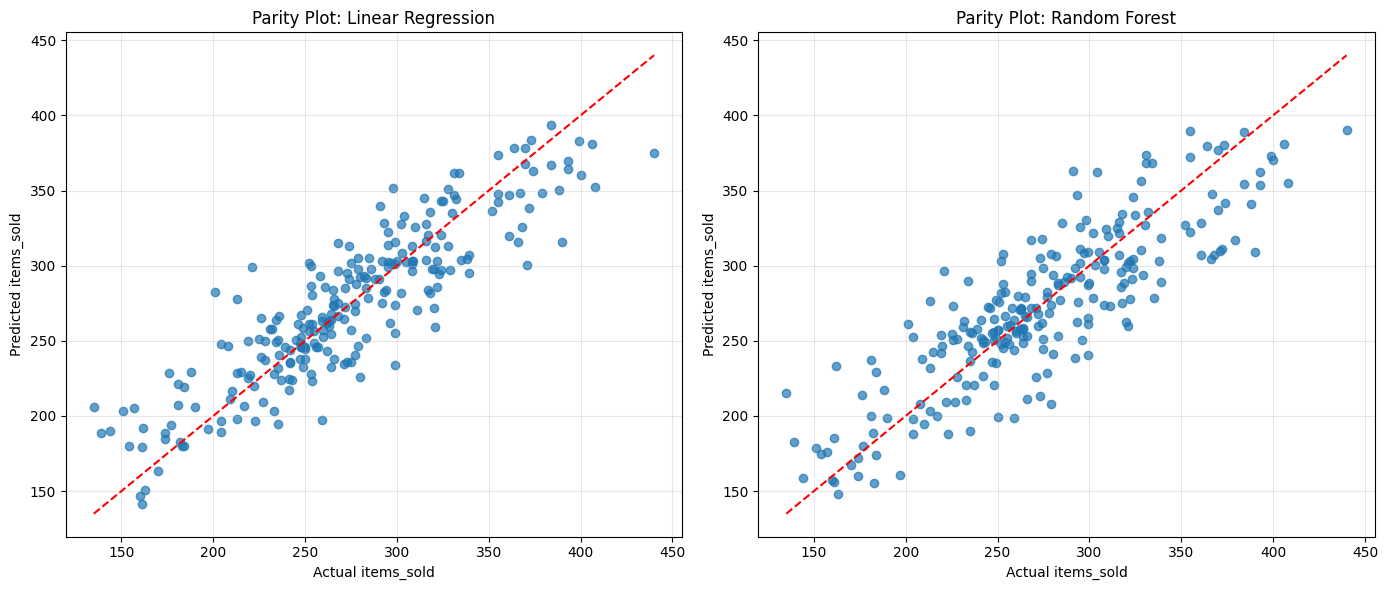

In [13]:
# Parity plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, pipe) in zip(axes, trained_pipelines.items()):
    y_pred = pipe.predict(x_train_test)
    ax.scatter(y_test, y_pred, alpha=0.7)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--")
    ax.set_title(f"Parity Plot: {name}")
    ax.set_xlabel("Actual items_sold")
    ax.set_ylabel("Predicted items_sold")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Feature importances from Random Forest
rf_pipe = trained_pipelines["Random Forest"]
preprocessor_fitted = rf_pipe.named_steps["preprocessor"]
rf_model = rf_pipe.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
2,num__is_festival,0.176175
18,cat__store_size_small,0.162664
15,cat__location_type_urban,0.111594
6,num__day_of_week,0.085278
1,num__is_weekend,0.063324
0,num__store_id,0.053927
13,cat__location_type_rural,0.051607
16,cat__store_size_large,0.050466
3,num__competition_density,0.050118
5,num__month,0.037575


In [16]:
# Top 5 most influential features
top5 = importance_df.head(5)
display(top5)

,feature,importance
2,num__is_festival,0.176175
18,cat__store_size_small,0.162664
15,cat__location_type_urban,0.111594
6,num__day_of_week,0.085278
1,num__is_weekend,0.063324


/tmp/ipykernel_457/3722256700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x="importance", y="feature", palette="viridis")


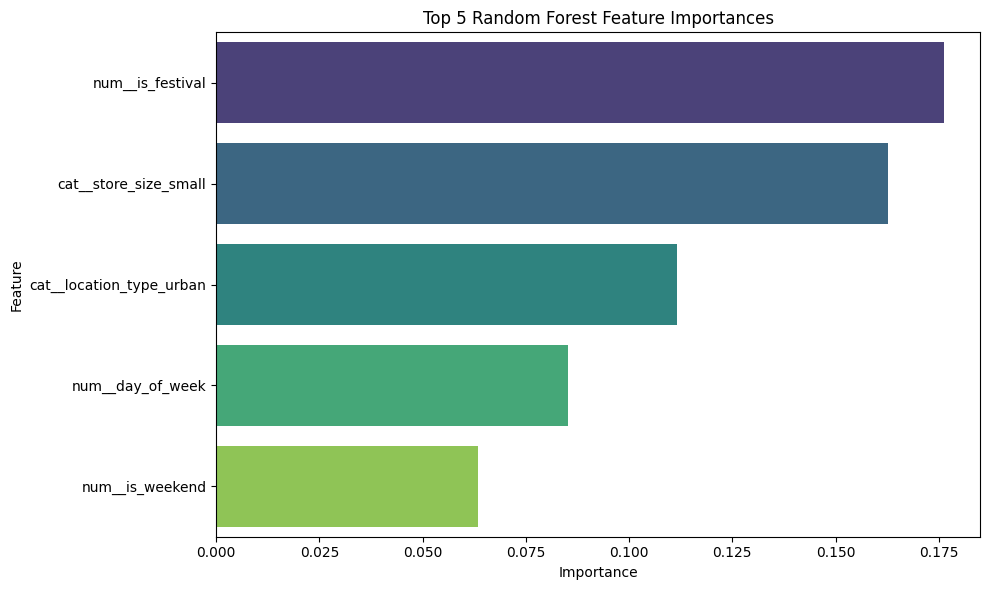

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top5, x="importance", y="feature", palette="viridis")
plt.title("Top 5 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Feature Importaance Interpretation

The most influential features are the ones with the largest Random Forest importance values. These features contribute most to predicting items_sold. If promotion-related or recency-related variables appear near the top, that suggests sales are strongly affected by promotional strategy and customer/store timing patterns.

Conclusion

The linear regression model provides a simple baseline, while the random forest regressor can capture non-linear relationships and interactions between store, promotion, and calendar features. The better model should be chosen based on lower RMSE and MAE on the chronological test set, since those metrics measure prediction error in the original sales units.